<a href="https://colab.research.google.com/github/ouchn2580201251107/05364_AI_programming_framework_ex5/blob/main/05364_AI_programming_framework_ex5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
pip install numpy pandas matplotlib seaborn scikit-learn

首先，我们加载该数据集

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
data=pd.read_csv('/content/drive/MyDrive/05364_AI_programming_framework/ex5/boston.csv')
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


下面是这些文件的列名及其对应的中文含义，整理成了Markdown表格的格式：

### Boston.csv
| 英语列名           | 中文列名         |
|--------------------------------|------------------------------|
| CRIM                          | 城镇人均犯罪率                   |
| ZN                            | 占地面积超过25，000平方英尺的住宅用地比例|
| INDUS                         | 每个城镇非零售业务的比例                     |
| CHAS                          | Charles River虚拟变量（如果是河道，则为1，否则为0）  |
| NOX                           | 一氧化氮浓度（每千万份）                     |
| RM                            |        每间住宅的平均房间数       |
| AGE                           | 1940年以前建造的自住单位比例                         |
| DIS                           | 波士顿的五个就业中心的加权距离             |
| RAD                           | 到达最近高速的距离                         |
| PTRATIO                       | 师生比例             |
| B                             | 城镇黑人比例                        |
| LSAST                         | 人口下降比例                 
| MEDV                         | 房屋价格       

### 数据预处理

在进行模型训练之前，我们需要对数据进行一些预处理操作，包括处理缺失值、数据标准化等。

In [9]:
# 检查是否有缺失值
print(data.isnull().sum())

# 数据标准化
from sklearn.preprocessing import StandardScaler

# 假设目标变量是 'MEDV'，特征列是其他所有列
X = data.drop('MEDV', axis=1)
y = data['MEDV']

# 标准化特征数据
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


### 数据可视化

通过可视化数据，我们可以更好地理解数据的分布和特征之间的关系

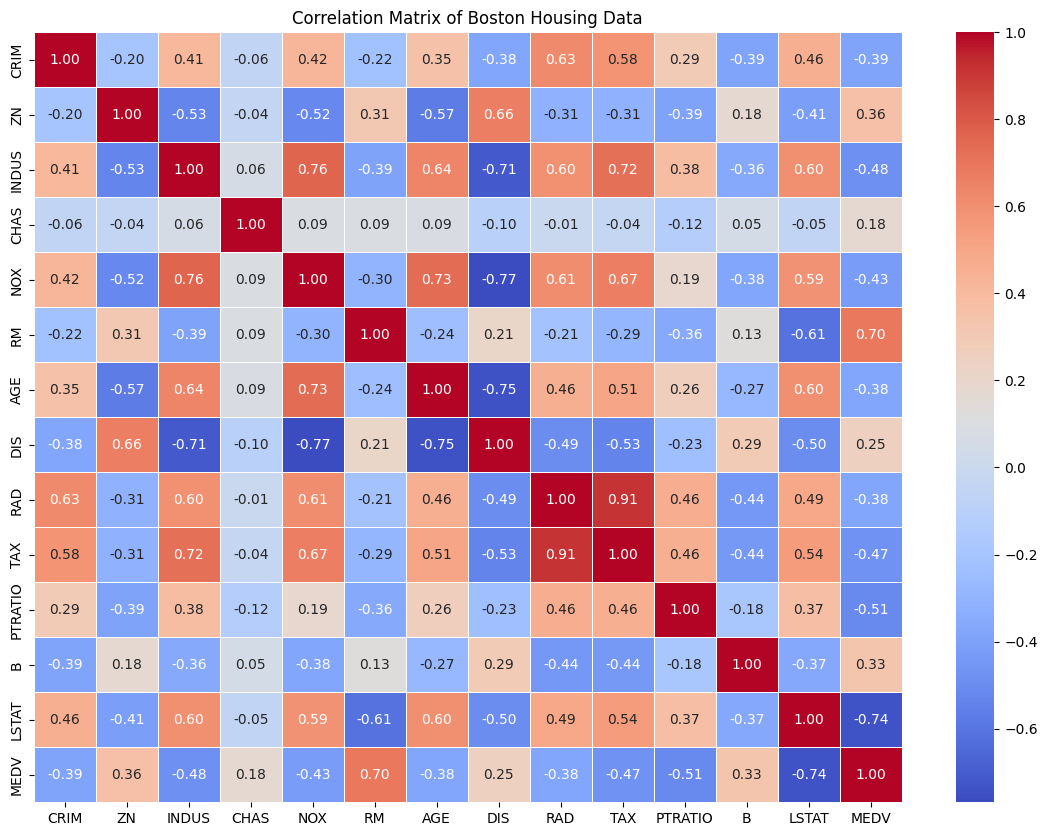

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt


# 计算相关性矩阵
corr = data.corr()

# 绘制热图
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of Boston Housing Data")
plt.show()

### 数据集划分

将数据集划分为训练集和测试集，以便进行模型训练和评估。

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=114514)

### 模型训练与评估

训练多个模型，并比较它们的性能。常用的模型包括线性回归、决策树回归、随机森林回归和支持向量回归。

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# 线性回归
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# 决策树回归
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

# 随机森林回归
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# 支持向量回归
svr = SVR()
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

# 输出模型性能
print("线性回归 - MSE: {:.2f}, R2: {:.2f}".format(mse_lr, r2_lr))
print("决策树 - MSE: {:.2f}, R2: {:.2f}".format(mse_dt, r2_dt))
print("随机森林 - MSE: {:.2f}, R2: {:.2f}".format(mse_rf, r2_rf))
print("支持向量 - MSE: {:.2f}, R2: {:.2f}".format(mse_svr, r2_svr))

线性回归 - MSE: 18.37, R2: 0.80
决策树 - MSE: 18.10, R2: 0.81
随机森林 - MSE: 12.00, R2: 0.87
支持向量 - MSE: 21.24, R2: 0.77


#### 模型性能比较

通过比较各个模型的MSE和R2分数，选择性能最好的模型。

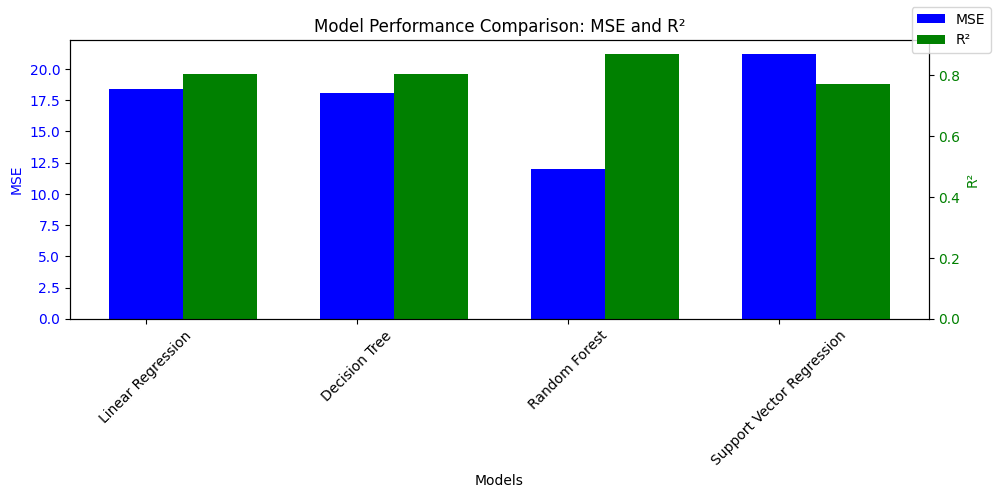

In [49]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Support Vector Regression']
mse_scores = [mse_lr, mse_dt, mse_rf, mse_svr]
r2_scores = [r2_lr, r2_dt, r2_rf, r2_svr]

# 创建画布，分成两个子图
fig, ax1 = plt.subplots(figsize=(10, 5))

# 绘制 MSE 条形图
bar_width = 0.35  # 每个条形的宽度
index = range(len(models))  # x轴的位置
ax1.bar(index, mse_scores, width=bar_width, color='blue', label='MSE')

# 设置 MSE 条形图的标签
ax1.set_xlabel('Models')
ax1.set_ylabel('MSE', color='blue')
ax1.set_title('Model Performance Comparison: MSE and R²')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(index)
ax1.set_xticklabels(models, rotation=45)

# 共享y轴的第二个坐标轴
ax2 = ax1.twinx()
ax2.bar([i + bar_width for i in index], r2_scores, width=bar_width, color='green', label='R²')

# 设置 R² 条形图的标签
ax2.set_ylabel('R²', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# 显示图例
fig.legend(loc='upper right')
plt.tight_layout()  # 自动调整布局
plt.show()

### 模型预测

基于训练好的模型进行预测，预测测试集中的房价，并与实际值进行对比。

In [50]:
best_model = rf

# 使用最佳模型进行预测
y_pred_best = best_model.predict(X_test)

# 输出预测结果
print("预测房价:", y_pred_best[:5])
print("实际房价:", y_test.values[:5])
print("偏差比例:", (y_pred_best[:5] / y_test.values[:5] - 1))



预测房价: [19.458 22.915 14.351 34.563 21.908]
实际房价: [23.  21.  13.6 33.4 20.6]
偏差比例: [-0.154       0.09119048  0.05522059  0.03482036  0.06349515]


In [51]:
best_model = lr

y_pred_best = best_model.predict(X_test)

print("预测房价:", y_pred_best[:5])
print("实际房价:", y_test.values[:5])
print("偏差比例:", (y_pred_best[:5] / y_test.values[:5] - 1))



预测房价: [20.08289481 20.55891039 12.33862035 28.26574454 27.22055425]
实际房价: [23.  21.  13.6 33.4 20.6]
偏差比例: [-0.12683066 -0.02100427 -0.0927485  -0.15372022  0.32138613]


In [52]:
best_model = dt

y_pred_best = best_model.predict(X_test)

# 输出预测结果
print("预测房价:", y_pred_best[:5])
print("实际房价:", y_test.values[:5])
print("偏差比例:", (y_pred_best[:5] / y_test.values[:5] - 1))



预测房价: [19.6 20.2 13.1 36.4 22.4]
实际房价: [23.  21.  13.6 33.4 20.6]
偏差比例: [-0.14782609 -0.03809524 -0.03676471  0.08982036  0.08737864]


In [53]:
best_model = svr

y_pred_best = best_model.predict(X_test)

# 输出预测结果
print("预测房价:", y_pred_best[:5])
print("实际房价:", y_test.values[:5])
print("偏差比例:", (y_pred_best[:5] / y_test.values[:5] - 1))



预测房价: [19.46180661 20.86001085 15.09697593 27.90611557 22.62449746]
实际房价: [23.  21.  13.6 33.4 20.6]
偏差比例: [-0.1538345  -0.00666615  0.11007176 -0.16448756  0.09827658]
